<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.5 MB/s eta 0:00:00


In [2]:
!pip install optuna

In [3]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 3.5 MB/s eta 0:00:00



--- [1. Optuna パラメータ最適化 (バックグラウンド実行)] ---

--- [2. 学習フェーズ開始 (Testデータは一切使用しません)] ---
>> Running Seed: 42...
>> Running Seed: 2023...
>> Running Seed: 777...

>> 🧠 司令塔（メタモデル）が各AIの信頼度を学習中...
▼ 司令塔が決定した各AIの信頼度（重み）:
  LightGBM: 1.8676 | XGBoost: 1.4314 | RandomForest: 1.6961
✅ 学習完了: スタッキング（メタモデル）の構築が完了しました！

📊 最終ローカルCVスコア (ROC-AUC): 0.8597
📉 最終損失 (Log Loss): 0.3205

--- [3. 予測フェーズ開始] ---
✅ 予測完了: 司令塔によるスタッキング予測を実行しました。

--- [4. エラー分析 (損失原因の特定)] ---
▼ 全体のエラー件数 (is_error = 1): 230 件 / 1568 件

▼ 損失原因度ランキング トップ5 (モデルを騙している戦犯):
                    Feature  Error_Importance
0            recent_loyalty         16.451671
1         campaign_affinity         12.027082
2  days_since_last_purchase          7.911143
3   days_since_registration          7.150573
4               spend_wines          7.045361

▼ AIがエラーを起こす条件ルール (is_error=1 になりやすい分岐):
|--- recent_loyalty <= 18.88
|   |--- days_since_registration <= 696.50
|   |   |--- days_since_last_purchase <= 31.50
|   |   |   |--- class: 0
|   |   |--- 

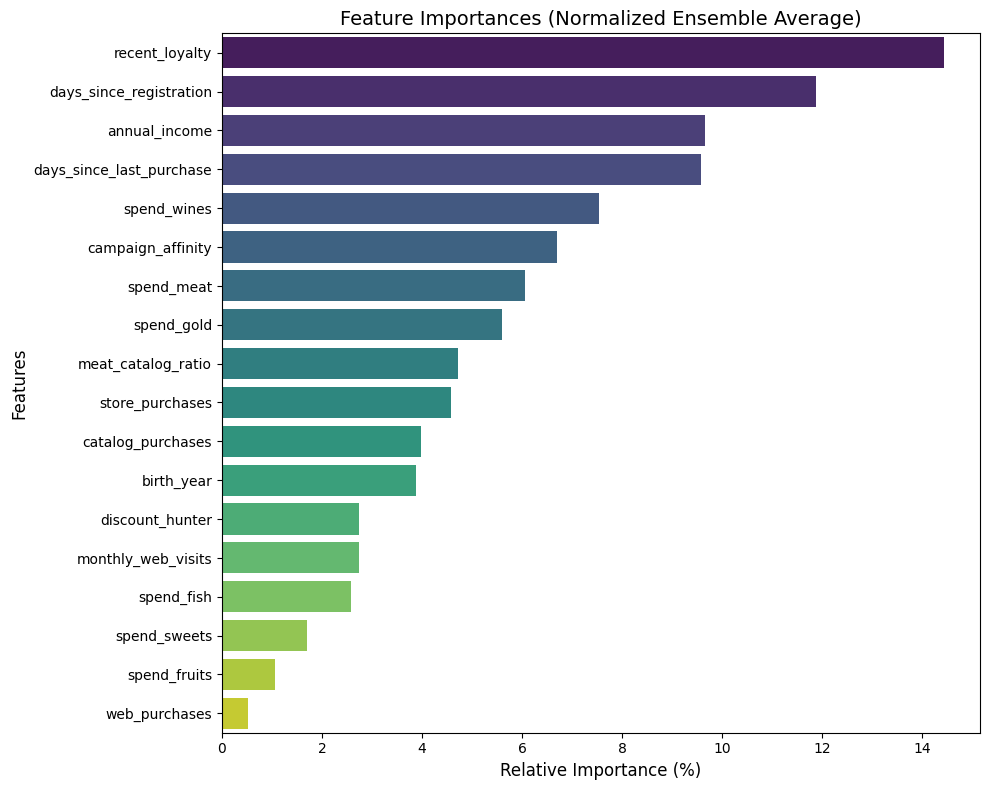


✅ 全工程完了: 'final_submission_stacking.csv' を出力しました！


In [12]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss  # 🌟 log_lossを追加
from sklearn.tree import DecisionTreeClassifier, export_text
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==========================================
# 0. 絶対にリークしない事前処理
# ==========================================
def preprocess_safe_row_wise(df):
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')

    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

    if all(c in df.columns for c in ['spend_wines', 'spend_meat', 'days_since_last_purchase']):
        df['recent_loyalty'] = (df['spend_wines'] + df['spend_meat']) / (df['days_since_last_purchase'] + 1)

    if all(c in df.columns for c in ['spend_meat', 'catalog_purchases']):
        df['meat_catalog_ratio'] = df['spend_meat'] / (df['catalog_purchases'] + 1)

    if all(c in df.columns for c in ['deals_purchases', 'store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        df['discount_hunter'] = df['deals_purchases'] / (total_purchases + 1)
        if 'recent_loyalty' in df.columns:
            df['campaign_affinity'] = df['recent_loyalty'] * df['discount_hunter']

    return df

# ==========================================
# 1. Optuna (LightGBMの調整)
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, n_trials=10):
    print("\n--- [1. Optuna パラメータ最適化 (バックグラウンド実行)] ---")
    def objective(trial):
        params = {
            'random_state': 42, 'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'class_weight': 'balanced', 'verbose': -1
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))
        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]
            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)
            model = LGBMClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_params
    best_params.update({'random_state': 42, 'n_estimators': 1000, 'class_weight': 'balanced', 'verbose': -1})
    return best_params

# ==========================================
# 2. 学習フェーズ & 🌟スタッキング(司令塔)の学習
# ==========================================
def train_models(X_raw, y, lgb_best_params, seeds=[42, 2023, 777], n_splits=5):
    print(f"\n--- [2. 学習フェーズ開始 (Testデータは一切使用しません)] ---")
    artifacts = []

    # 🌟 各AIの予測(OOF)を個別に保存するための配列
    oof_lgb = np.zeros(len(X_raw))
    oof_xgb = np.zeros(len(X_raw))
    oof_rf  = np.zeros(len(X_raw))

    ratio = float(np.sum(y == 0)) / np.sum(y == 1)

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            income_median = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)

            lgb_params = lgb_best_params.copy()
            lgb_params['random_state'] = seed

            models = {
                'LightGBM': LGBMClassifier(**lgb_params),
                'XGBoost': XGBClassifier(random_state=seed, n_estimators=1000, learning_rate=0.05, max_depth=5, scale_pos_weight=ratio, early_stopping_rounds=50, eval_metric='logloss'),
                'RandomForest': RandomForestClassifier(random_state=seed, n_estimators=100, max_depth=10, class_weight='balanced')
            }

            models['LightGBM'].fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
            models['XGBoost'].fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            models['RandomForest'].fit(X_tr, y_tr)

            # 🌟 各AIの予測を個別に加算（シード数で割って平均化）
            oof_lgb[val_idx] += models['LightGBM'].predict_proba(X_va)[:, 1] / len(seeds)
            oof_xgb[val_idx] += models['XGBoost'].predict_proba(X_va)[:, 1] / len(seeds)
            oof_rf[val_idx]  += models['RandomForest'].predict_proba(X_va)[:, 1] / len(seeds)

            artifacts.append({
                'seed': seed, 'fold': fold,
                'preprocessors': {'income_median': income_median},
                'models': models, 'feature_names': list(X_tr.columns)
            })

    # ==========================================
    # 🌟 メタモデル（司令塔）の学習
    # ==========================================
    print("\n>> 🧠 司令塔（メタモデル）が各AIの信頼度を学習中...")
    # 3つのAIの予測結果を特徴量としてまとめる
    meta_X = pd.DataFrame({'LightGBM': oof_lgb, 'XGBoost': oof_xgb, 'RandomForest': oof_rf})

    # ロジスティック回帰に「最終的な正解(y)」との答え合わせをさせる
    meta_model = LogisticRegression(random_state=42)
    meta_model.fit(meta_X, y)

    weights = meta_model.coef_[0]
    print(f"▼ 司令塔が決定した各AIの信頼度（重み）:")
    print(f"  LightGBM: {weights[0]:.4f} | XGBoost: {weights[1]:.4f} | RandomForest: {weights[2]:.4f}")

    # 司令塔による最終的なOOF予測（これが分析グラフのベースになります）
    final_oof_preds = meta_model.predict_proba(meta_X)[:, 1]

    print(f"✅ 学習完了: スタッキング（メタモデル）の構築が完了しました！")
    return artifacts, meta_model, final_oof_preds

# ==========================================
# 3. 予測フェーズ & 🌟メタモデルによる最終決断
# ==========================================
def predict_models(X_test_raw, artifacts, meta_model):
    print("\n--- [3. 予測フェーズ開始] ---")

    # 🌟 テストデータに対する各AIの予測を個別に保存
    test_lgb = np.zeros(len(X_test_raw))
    test_xgb = np.zeros(len(X_test_raw))
    test_rf  = np.zeros(len(X_test_raw))

    total_folds = len(artifacts)

    for artifact in artifacts:
        X_te = X_test_raw.copy()
        preps = artifact['preprocessors']
        models = artifact['models']

        X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])

        test_lgb += models['LightGBM'].predict_proba(X_te)[:, 1] / total_folds
        test_xgb += models['XGBoost'].predict_proba(X_te)[:, 1] / total_folds
        test_rf  += models['RandomForest'].predict_proba(X_te)[:, 1] / total_folds

    # 🌟 司令塔（メタモデル）に、3つのAIの意見を提出して最終判断を下させる
    meta_X_test = pd.DataFrame({'LightGBM': test_lgb, 'XGBoost': test_xgb, 'RandomForest': test_rf})
    final_test_preds = meta_model.predict_proba(meta_X_test)[:, 1]

    print(f"✅ 予測完了: 司令塔によるスタッキング予測を実行しました。")
    return final_test_preds

# ==========================================
# 4 & 5. 可視化・分析 (変更なし)
# ==========================================
def analyze_error_patterns(X_raw, y, oof_preds):
    print("\n--- [4. エラー分析 (損失原因の特定)] ---")
    error_df = X_raw.copy()
    error_df['target'] = y
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)
    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)
    print(f"▼ 全体のエラー件数 (is_error = 1): {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    X_error = X_raw.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())
    error_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])
    error_importance = pd.DataFrame({'Feature': X_error.columns, 'Error_Importance': error_model.feature_importances_ * 100}).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)

    print("\n▼ 損失原因度ランキング トップ5 (モデルを騙している戦犯):")
    print(error_importance.head(5))

    dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
    dt.fit(X_error, error_df['is_error'])
    print("\n▼ AIがエラーを起こす条件ルール (is_error=1 になりやすい分岐):")
    print(export_text(dt, feature_names=list(X_error.columns)))
    return error_importance

def plot_feature_importances(artifacts):
    print("\n--- [5. 特徴量重要度の算出] ---")
    f_names = artifacts[0]['feature_names']
    importance_df = pd.DataFrame({'Feature': f_names})
    total_imps = np.zeros(len(f_names))
    total_models = 0
    scaler = MinMaxScaler()
    for art in artifacts:
        for name, model in art['models'].items():
            raw_imp = model.feature_importances_
            scaled_imp = scaler.fit_transform(raw_imp.reshape(-1, 1)).flatten()
            total_imps += scaled_imp
            total_models += 1

    importance_df['Total_Average'] = (total_imps / total_models)
    importance_df['Total_Average'] = (importance_df['Total_Average'] / importance_df['Total_Average'].sum()) * 100
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Total_Average', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importances (Normalized Ensemble Average)', fontsize=14)
    plt.xlabel('Relative Importance (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()
    return importance_df

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    noise_features = [
        'has_complaint', 'education_level', 'marital_status',
        'num_children', 'deals_purchases', 'num_teenagers'
    ]

    X_raw = train_df.drop(['customer_id', 'target'] + noise_features, axis=1)
    y = train_df['target']
    X_test_raw = test_df.drop(['customer_id'] + noise_features, axis=1, errors='ignore')

    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, n_trials=10)

    # 🌟 メタモデルを受け取るように変更
    artifacts, meta_model, oof_predictions = train_models(X_raw, y, best_lgb_params)

    # 🌟 最終的なローカルCVスコアと損失の計算・表示を追加
    final_cv_auc = roc_auc_score(y, oof_predictions)
    final_cv_loss = log_loss(y, oof_predictions)
    print(f"\n📊 最終ローカルCVスコア (ROC-AUC): {final_cv_auc:.4f}")
    print(f"📉 最終損失 (Log Loss): {final_cv_loss:.4f}")

    # 🌟 予測時にメタモデルも渡す
    final_predictions = predict_models(X_test_raw, artifacts, meta_model)

    analyze_error_patterns(X_raw, y, oof_predictions)
    plot_feature_importances(artifacts)

    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_stacking.csv', index=False)
    print("\n✅ 全工程完了: 'final_submission_stacking.csv' を出力しました！")